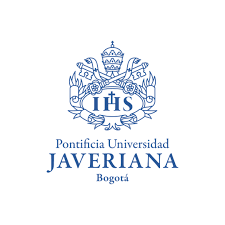
***Pontificia Universidad Javeriana***
# **Procesamiento de Alto Volumen de Datos**

### **Proyecto de procesamiento de altos volúmenes de datos**

Grupo Sigma


Fecha actual: 24/05/2026

En este cuaderno se pretende responder a las preguntas de negocio planteadas por el equipo.

# Configuracion inicial

In [1]:
### Importación de bibliotecas basicas 
import os                       # -> Para gestion de archivos y procesos
import sys                      # -> Para manejo de recursos del sistema
import pandas as pd             # -> Para graficar y objetos dataframe
import numpy as np              # -> Para algebra matricial
import matplotlib.pyplot as plt # -> Para formatos de graficas
import seaborn as sns           # -> Para estadistica y graficar
### Importacion de bibliotecas especializadas
import findspark                                # -> Para manejo del entorno de PySpark
findspark.init('/Almacen/Spark')                # -> Se inicia el entorno para PySpark
from pyspark import SparkConf, SparkContext     # -> Para contexto y configuración de PySpark
from pyspark.sql import SparkSession            # -> Para manejo de Sesion en entorno de consultas SQL
from pyspark.sql.functions import *             # -> Para funciones de manipulacion de columnas
from pyspark.sql.types import IntegerType, StringType, DoubleType # -> Para definir tipos de datos


In [2]:
configura = SparkConf()
configura.set('spark.scheduler.mode', 'FAIR')
configura.set('spark.scheduler.allocation','/Almacen/Spark/conf/fairscheduler.xml')
configura.setMaster('spark://10.43.97.166:7077')
configura.setAppName('SigmaSPARK')

sparkSigma = SparkSession.builder.config(conf=configura).getOrCreate()
sparkSigma

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/25 16:27:50 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## Lectura de los datos

In [3]:
## Se crea el dataframe para acceder al sistema de fichero csv como un objeto dataframe pyspark
## El acceso se hara desde el sistema de ficheros Hadoop HDFS
datosInternet = sparkSigma.read.format("csv").option("header","true").option("encoding", "UTF-8").load("../ProyectoPruebas/DatosLimpiosInternet.csv")
datosInternet.show(5)

+----+---------+--------------------+-------+------------+-------+-------------+--------------------+----------+----------+----------+-----------+-----------------+---------------+
| AÑO|TRIMESTRE|           PROVEEDOR|COD_DEP|     NOM_DEP|COD_MUN|      NOM_MUN|            SEGMENTO|TECNOLOGIA|VEL_BAJADA|VEL_SUBIDA|NUM_ACCESOS|SEGMENTO_AGRUPADO|TIPO_TECNOLOGIA|
+----+---------+--------------------+-------+------------+-------+-------------+--------------------+----------+----------+----------+-----------+-----------------+---------------+
|2020|        3|CONEXION DIGITAL ...|     70|       SUCRE|  70215|      COROZAL|    SIN ESTRATIFICAR|     CABLE|      10.0|       3.0|         36|             OTRO|          CABLE|
|2020|        4|COMUNICACION CELU...|     73|      TOLIMA|  73001|      IBAGUI|RESIDENCIAL - EST...|     CABLE|      45.0|       6.0|        183|      RESIDENCIAL|          CABLE|
|2019|        2|COMUNICACION CELU...|     50|        META|  50001|VILLAVICENCIO|RESIDENCIAL - E

In [4]:
# Se ha observado que existen algunos nombres con caracteres especiales se implementa la funcion que permitirá poner bien los nombres de las columnas
import re

def limpiar_columna(nombre):
    reemplazos = {
        "á": "a", "é": "e", "í": "i", "ó": "o", "ú": "u",
        "Á": "A", "É": "E", "Í": "I", "Ó": "O", "Ú": "U",
        "ñ": "n", "Ñ": "N", " ": "_"
    }
    for original, nuevo in reemplazos.items():
        nombre = nombre.replace(original, nuevo)
    return nombre

new_columns = [limpiar_columna(col) for col in datosInternet.columns]
datosInternet = datosInternet.toDF(*new_columns)
datosInternet.show(1)

[Stage 2:>                                                          (0 + 1) / 1]

+----+---------+--------------------+-------+-------+-------+-------+----------------+----------+----------+----------+-----------+-----------------+---------------+
| ANO|TRIMESTRE|           PROVEEDOR|COD_DEP|NOM_DEP|COD_MUN|NOM_MUN|        SEGMENTO|TECNOLOGIA|VEL_BAJADA|VEL_SUBIDA|NUM_ACCESOS|SEGMENTO_AGRUPADO|TIPO_TECNOLOGIA|
+----+---------+--------------------+-------+-------+-------+-------+----------------+----------+----------+----------+-----------+-----------------+---------------+
|2020|        3|CONEXION DIGITAL ...|     70|  SUCRE|  70215|COROZAL|SIN ESTRATIFICAR|     CABLE|      10.0|       3.0|         36|             OTRO|          CABLE|
+----+---------+--------------------+-------+-------+-------+-------+----------------+----------+----------+----------+-----------+-----------------+---------------+
only showing top 1 row



In [5]:
## Se crea el dataframe para acceder al sistema de fichero csv como un objeto dataframe pyspark
## El acceso se hara desde el sistema de ficheros Hadoop HDFS
datosIcfes = sparkSigma.read.format("csv").option("header","true").option("encoding", "UTF-8").load("../ProyectoPruebas/DatosIcfesLimpios.csv")
datosIcfes.show(2)


26/05/25 16:28:08 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+----------------+------------+-------------+----------+-------------+-----------------------------+------------------+------------------------+------------------------+-----------------+-------------+-----------+--------+--------------------+----------+--------------------+--------------------+-------------------+---------------------------+---------------------------+---------------------+---------------------+-----------------------+-----------------+------------------------+---------------+------+-----------------------+-----------------+-----------------+---------------------+-------------+---------+----------+-------+--------------+-------------------+----------------+--------------+------------------+-------------+-----------+---------+-------------+-------------+------------+-----------+
|PERIODO|   ID_ESTUDIANTE|AREA_COLEGIO|COLE_BILINGUE|CALENDARIO|COLE_CARACTER|COLE_COD_DANE_ESTABLECIMIENTO|COLE_COD_DANE_SEDE|COLE_COD_DEPTO_UBICACION|COLE_COD_MCPIO_UBICACION|COLE_COD

In [6]:
## Se crea el dataframe para acceder al sistema de fichero csv como un objeto dataframe pyspark
## El acceso se hara desde el sistema de ficheros Hadoop HDFS
datosPobreza = sparkSigma.read.format("csv").option("header","true").option("encoding", "UTF-8").load("../ProyectoPruebas/DatosLimpiosPobreza.csv")
datosPobreza.show(5)

+-------+------------------+----------------+-------------------+-------------+---------------+-----------------+-----------------------------+------------------+------------------------+------------------------+-----------------+--------------------+-----------+------------+--------------------+---------------+---------------------------+--------------------+-------------------+---------------------------+---------------------------+---------------------+---------------------+-----------------------+-----------------+------------------------+---------------+--------------------+-----------+-----------------------+-----------------+-----------------+----------------+---------------------+-----------------+--------------------+--------------------+--------------------+------------------+-------------------+--------------------+------------------+------------------+-------------+-----------+
|PERIODO|ESTU_TIPODOCUMENTO|ESTU_CONSECUTIVO|COLE_AREA_UBICACION|COLE_BILINGUE|COLE_CALENDARIO|  

In [36]:
datosIMRC = sparkSigma.read.format("csv").option("header","true").option("encoding", "UTF-8").load("../ProyectoPruebas/datos_limpios_IMRC_Hoja2.csv")
datosIMRC.show(5)

[Stage 181:>                                                        (0 + 1) / 1]

+---+--------+------------+--------+-----------+--------------+-------+-------+-------+--------+-----------------+-------------------+---------------------+-----------------------+----------+------------+----+------------------------+----------------+--------------------+-------------------+-------------------+--------+---------------+------+---------+------------+--------------------+-----------------------+-------------------+----+---------------+--------------------+------+
| ID|COD_DPTO|DEPARTAMENTO|DIVIPOLA|  MUNICIPIO|TIPO_MUNICIPIO| ASE_HA|PCT_ASE|ASIF_HA|PCT_ASIF|EXPOSICION_SEQUIA|EXPOSICION_INCENDIO|VULNERABILIDAD_SEQUIA|VULNERABILIDAD_INCENDIO|IRD_SEQUIA|IRD_INCENDIO|IR_D|VALOR_AGREGADO_PERCAPITA|PCT_POB_CABECERA|DENSIDAD_EMPRESARIAL|PCT_VA_AGROPECUARIO|COMP_SOCIOECONOMICO|COMP_MDM|COMP_FINANCIERO| CMGRD|    PMGRD|        EMRE|NUM_HERRAMIENTAS_GRD|INVERSION_GRD_PERCAPITA|COMP_GESTION_RIESGO|IC_D|GRUPO_CAPACIDAD|DISTANCIA_EUCLIDIANA|IMRC_D|
+---+--------+------------+--------+

# Primera pregunta. ¿Cómo afecta la conectividad a internet a los resultados del ICFES en general?


Del análisis exploratorio en el conjunto de datos de los resultados icfes, podemos retomar esta visualización:

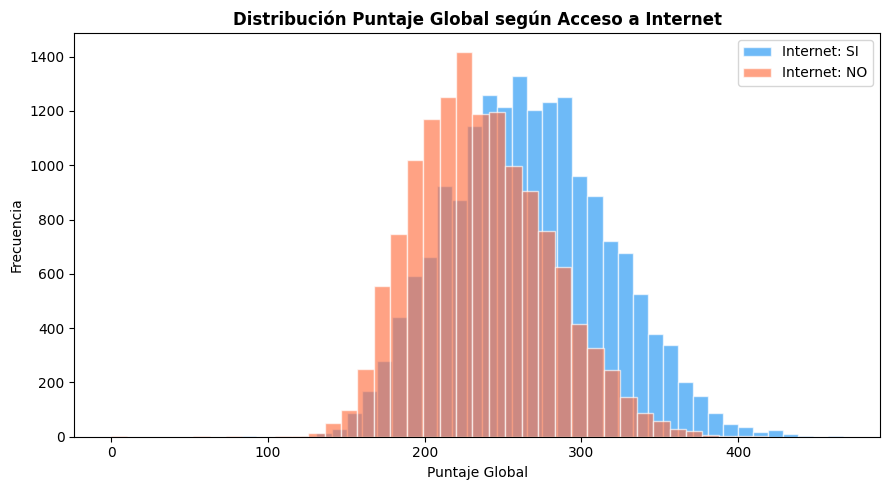

De esto se puede concluir que si éxiste una diferencia significativa entre las personas que tienen internet y las que no, pues la distribución de las personas que tienen internet esta desplazada hacia la derecha, es decir, tendencia hacia mayor puntaje, lo contrario ocurre con la distribución de las personas que no tienen internet

**Respuesta**:  Tener conectividad a internet afecta positivamente a un buen puntaje icfes

# Segunda pregunta. ¿Cómo afectan los índices de pobreza a los resultados del ICFES?


In [7]:
from pyspark.sql import functions as F


# PUNTO 2 - NORMALIZACIÓN DE LA BASE POBREZA

# Esta base tiene nombres originales tipo ICFES:
# COLE_MCPIO_UBICACION, FAMI_ESTRATOVIVIENDA,
# FAMI_EDUCACIONMADRE, FAMI_EDUCACIONPADRE, etc.

pobrezaNormalizada = datosPobreza.select(
    F.upper(F.trim(F.col("COLE_MCPIO_UBICACION"))).alias("NOM_MUN"),
    F.upper(F.trim(F.col("COLE_DEPTO_UBICACION"))).alias("DEPTO"),

    F.regexp_extract(
        F.col("FAMI_ESTRATOVIVIENDA").cast("string"),
        r"(\d+)",
        1
    ).cast("double").alias("ESTRATO_POBREZA"),

    F.upper(F.trim(F.col("FAMI_EDUCACIONMADRE"))).alias("EDU_MADRE_POBREZA"),
    F.upper(F.trim(F.col("FAMI_EDUCACIONPADRE"))).alias("EDU_PADRE_POBREZA"),
    F.upper(F.trim(F.col("FAMI_TIENECOMPUTADOR"))).alias("TIENE_COMPUTADOR_POBREZA"),

    F.col("PUNT_GLOBAL").cast("double").alias("PUNT_GLOBAL_POBREZA")
)

print("Registros base pobreza normalizada:", pobrezaNormalizada.count())

pobrezaNormalizada.show(10, truncate=False)

Registros base pobreza normalizada: 2331101
+-----------+---------+---------------+------------------------------------+----------------------------------+------------------------+-------------------+
|NOM_MUN    |DEPTO    |ESTRATO_POBREZA|EDU_MADRE_POBREZA                   |EDU_PADRE_POBREZA                 |TIENE_COMPUTADOR_POBREZA|PUNT_GLOBAL_POBREZA|
+-----------+---------+---------------+------------------------------------+----------------------------------+------------------------+-------------------+
|AIPE       |HUILA    |2.0            |POSTGRADO                           |PRIMARIA COMPLETA                 |SI                      |339.0              |
|AIPE       |HUILA    |2.0            |POSTGRADO                           |PRIMARIA COMPLETA                 |SI                      |339.0              |
|LA PLATA   |HUILA    |1.0            |PRIMARIA INCOMPLETA                 |PRIMARIA INCOMPLETA               |NO                      |199.0              |
|LA PLATA   |H

In [8]:
# Esta base tiene nombres ya transformados:
# COLE_MCPIO_UBICACION, DEPTO_COLEGIO, ESTRATO,
# EDU_MADRE, EDU_PADRE, TIENE_COMPUTADOR, PUNT_GLOBAL.

icfesNormalizado = datosIcfes.select(
    F.upper(F.trim(F.col("COLE_MCPIO_UBICACION"))).alias("NOM_MUN"),
    F.upper(F.trim(F.col("DEPTO_COLEGIO"))).alias("DEPTO"),

    F.col("ESTRATO").cast("double").alias("ESTRATO_ICFES"),
    F.upper(F.trim(F.col("EDU_MADRE"))).alias("EDU_MADRE_ICFES"),
    F.upper(F.trim(F.col("EDU_PADRE"))).alias("EDU_PADRE_ICFES"),
    F.upper(F.trim(F.col("TIENE_COMPUTADOR"))).alias("TIENE_COMPUTADOR_ICFES"),

    F.col("PUNT_GLOBAL").cast("double").alias("PUNT_GLOBAL_ICFES"),
    F.col("PUNT_MATE").cast("double").alias("PUNT_MATE"),
    F.col("PUNT_LECTURA").cast("double").alias("PUNT_LECTURA"),
    F.col("PUNT_CIENCIAS").cast("double").alias("PUNT_CIENCIAS"),
    F.col("PUNT_SOCIALES").cast("double").alias("PUNT_SOCIALES"),
    F.col("PUNT_INGLES").cast("double").alias("PUNT_INGLES")
)

print("Registros base ICFES normalizada:", icfesNormalizado.count())

icfesNormalizado.show(10, truncate=False)

Registros base ICFES normalizada: 27005
+------------+---------------+-------------+------------------------------+---------------+----------------------+-----------------+---------+------------+-------------+-------------+-----------+
|NOM_MUN     |DEPTO          |ESTRATO_ICFES|EDU_MADRE_ICFES               |EDU_PADRE_ICFES|TIENE_COMPUTADOR_ICFES|PUNT_GLOBAL_ICFES|PUNT_MATE|PUNT_LECTURA|PUNT_CIENCIAS|PUNT_SOCIALES|PUNT_INGLES|
+------------+---------------+-------------+------------------------------+---------------+----------------------+-----------------+---------+------------+-------------+-------------+-----------+
|FLORENCIA   |CAQUETA        |1.0          |PRIMARIA                      |PRIMARIA       |NO                    |213.0            |39.0     |42.0        |44.0         |45.0         |44.0       |
|MONTERÍA    |CORDOBA        |1.0          |PRIMARIA                      |SECUNDARIA     |NO                    |315.0            |66.0     |64.0        |61.0         |65.0   

In [9]:
pobrezaMunicipal = pobrezaNormalizada \
    .groupBy("NOM_MUN") \
    .agg(
        F.avg("ESTRATO_POBREZA").alias("ESTRATO_PROM_POBREZA"),
        F.avg("PUNT_GLOBAL_POBREZA").alias("PROM_ICFES_POBREZA"),
        F.count("*").alias("N_REGISTROS_POBREZA")
    ) \
    .dropna(subset=["NOM_MUN", "ESTRATO_PROM_POBREZA"])

icfesMunicipal = icfesNormalizado \
    .groupBy("NOM_MUN") \
    .agg(
        F.avg("PUNT_GLOBAL_ICFES").alias("PROM_ICFES"),
        F.avg("ESTRATO_ICFES").alias("ESTRATO_PROM_ICFES"),
        F.count("*").alias("N_REGISTROS_ICFES")
    ) \
    .dropna(subset=["NOM_MUN", "PROM_ICFES"])

print("Municipios en pobreza:", pobrezaMunicipal.count())
print("Municipios en ICFES:", icfesMunicipal.count())

print("\nBase pobreza municipal:")
pobrezaMunicipal.orderBy("NOM_MUN").show(10, truncate=False)

print("\nBase ICFES municipal:")
icfesMunicipal.orderBy("NOM_MUN").show(10, truncate=False)

Municipios en pobreza: 1394


Municipios en ICFES: 1236

Base pobreza municipal:


+---------+--------------------+------------------+-------------------+
|NOM_MUN  |ESTRATO_PROM_POBREZA|PROM_ICFES_POBREZA|N_REGISTROS_POBREZA|
+---------+--------------------+------------------+-------------------+
|ABEJORRAL|1.5845347313237221  |251.2896103896104 |770                |
|ABREGO   |1.3862359550561798  |254.4427374301676 |716                |
|ABRIAQUI |1.7472527472527473  |231.56521739130434|92                 |
|ABRIAQUÍ |1.75                |242.16666666666666|36                 |
|ACACIAS  |1.7819757365684576  |255.49567623659632|2891               |
|ACACÍAS  |1.9900579950289976  |254.58697444352845|1213               |
|ACANDI   |1.145922746781116   |210.5084745762712 |236                |
|ACANDÍ   |1.6290322580645162  |198.60629921259843|127                |
|ACEVEDO  |1.4017278617710582  |230.4580369843528 |1406               |
|ACHI     |1.1025316455696204  |209.64468864468864|819                |
+---------+--------------------+------------------+-------------

In [10]:
# JOIN MUNICIPAL ENTRE POBREZA E ICFES


comparacionPobreza = icfesMunicipal.join(
    pobrezaMunicipal,
    on="NOM_MUN",
    how="inner"
)

comparacionPobreza = comparacionPobreza.withColumn(
    "INDICE_SOCIOECONOMICO",
    F.coalesce(
        F.col("ESTRATO_PROM_POBREZA"),
        F.col("ESTRATO_PROM_ICFES")
    )
)

comparacionPobreza = comparacionPobreza.dropna(
    subset=["NOM_MUN", "PROM_ICFES", "INDICE_SOCIOECONOMICO"]
)

print("Municipios cruzados entre pobreza e ICFES:", comparacionPobreza.count())

comparacionPobreza \
    .select(
        "NOM_MUN",
        "PROM_ICFES",
        "ESTRATO_PROM_POBREZA",
        "ESTRATO_PROM_ICFES",
        "INDICE_SOCIOECONOMICO",
        "N_REGISTROS_POBREZA",
        "N_REGISTROS_ICFES"
    ) \
    .orderBy(F.col("INDICE_SOCIOECONOMICO").asc()) \
    .show(15, truncate=False)

Municipios cruzados entre pobreza e ICFES: 1233


[Stage 43:==============================================>         (10 + 2) / 12]

+---------------------------+------------------+--------------------+------------------+---------------------+-------------------+-----------------+
|NOM_MUN                    |PROM_ICFES        |ESTRATO_PROM_POBREZA|ESTRATO_PROM_ICFES|INDICE_SOCIOECONOMICO|N_REGISTROS_POBREZA|N_REGISTROS_ICFES|
+---------------------------+------------------+--------------------+------------------+---------------------+-------------------+-----------------+
|YAVARATE                   |173.0             |1.0                 |1.0               |1.0                  |32                 |1                |
|MURINDÓ                    |200.0             |1.0                 |1.0               |1.0                  |22                 |1                |
|CHALAN                     |222.0             |1.0279329608938548  |1.0               |1.0279329608938548   |181                |1                |
|COLON (GENOVA)             |265.3333333333333 |1.028436018957346   |1.0               |1.028436018957346 

In [11]:
# VALIDACIÓN DEL CRUCE MUNICIPAL


total_municipios_pobreza = pobrezaMunicipal.count()
total_municipios_icfes = icfesMunicipal.count()
total_municipios_cruzados = comparacionPobreza.count()

porcentaje_cruce_icfes = (
    total_municipios_cruzados / total_municipios_icfes * 100
    if total_municipios_icfes > 0 else 0
)

porcentaje_cruce_pobreza = (
    total_municipios_cruzados / total_municipios_pobreza * 100
    if total_municipios_pobreza > 0 else 0
)

print("Municipios en base pobreza:", total_municipios_pobreza)
print("Municipios en base ICFES:", total_municipios_icfes)
print("Municipios cruzados:", total_municipios_cruzados)

print(f"Porcentaje de municipios ICFES cruzados: {porcentaje_cruce_icfes:.2f}%")
print(f"Porcentaje de municipios pobreza cruzados: {porcentaje_cruce_pobreza:.2f}%")

[Stage 65:>                                                         (0 + 1) / 1]

Municipios en base pobreza: 1394
Municipios en base ICFES: 1236
Municipios cruzados: 1233
Porcentaje de municipios ICFES cruzados: 99.76%
Porcentaje de municipios pobreza cruzados: 88.45%


In [12]:
# CONVERSIÓN A PANDAS Y CORRELACIÓN


import pandas as pd
from scipy.stats import pearsonr

pdfPobreza = comparacionPobreza.toPandas()

columnas_numericas = [
    "PROM_ICFES",
    "ESTRATO_PROM_POBREZA",
    "ESTRATO_PROM_ICFES",
    "INDICE_SOCIOECONOMICO",
    "N_REGISTROS_POBREZA",
    "N_REGISTROS_ICFES"
]

for columna in columnas_numericas:
    pdfPobreza[columna] = pd.to_numeric(pdfPobreza[columna], errors="coerce")

pdfPobreza = pdfPobreza.dropna(
    subset=["PROM_ICFES", "INDICE_SOCIOECONOMICO"]
)

r_socioeconomico, p_socioeconomico = pearsonr(
    pdfPobreza["INDICE_SOCIOECONOMICO"],
    pdfPobreza["PROM_ICFES"]
)

print("Municipios usados para la correlación:", len(pdfPobreza))
print(f"Correlación índice socioeconómico vs puntaje ICFES: {r_socioeconomico:.3f}")
print(f"Valor p: {p_socioeconomico:.4f}")

pdfPobreza.head()

Municipios usados para la correlación: 1233
Correlación índice socioeconómico vs puntaje ICFES: 0.231
Valor p: 0.0000


,NOM_MUN,PROM_ICFES,ESTRATO_PROM_ICFES,N_REGISTROS_ICFES,ESTRATO_PROM_POBREZA,PROM_ICFES_POBREZA,N_REGISTROS_POBREZA,INDICE_SOCIOECONOMICO
0,ARMENIA,260.050847,2.212644,177,2.300202,261.480612,16402,2.300202
1,VILLAMARÍA,240.333333,1.833333,6,3.237057,286.803235,742,3.237057
2,SAN PABLO,240.967742,1.066667,31,1.318230,243.403866,1966,1.318230
3,MAHATES,203.000000,1.333333,22,1.298393,207.913872,1521,1.298393
4,BRICEÑO,179.000000,2.000000,1,1.482036,233.964497,338,1.482036


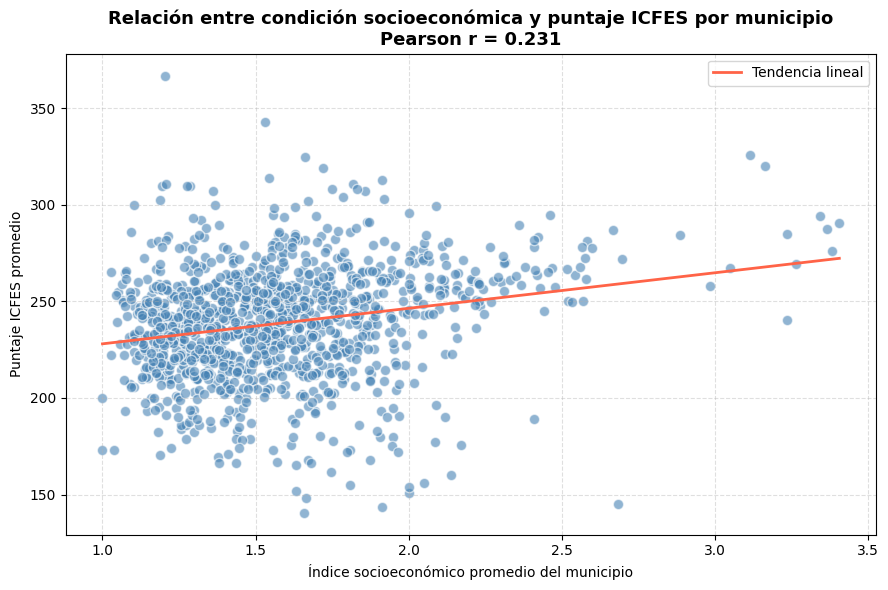

In [13]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(9, 6))

plt.scatter(
    pdfPobreza["INDICE_SOCIOECONOMICO"],
    pdfPobreza["PROM_ICFES"],
    alpha=0.6,
    color="steelblue",
    edgecolors="white",
    s=55
)

m, b = np.polyfit(
    pdfPobreza["INDICE_SOCIOECONOMICO"],
    pdfPobreza["PROM_ICFES"],
    1
)

x_range = np.linspace(
    pdfPobreza["INDICE_SOCIOECONOMICO"].min(),
    pdfPobreza["INDICE_SOCIOECONOMICO"].max(),
    100
)

plt.plot(
    x_range,
    m * x_range + b,
    color="tomato",
    linewidth=2,
    label="Tendencia lineal"
)

plt.title(
    f"Relación entre condición socioeconómica y puntaje ICFES por municipio\nPearson r = {r_socioeconomico:.3f}",
    fontsize=13,
    fontweight="bold"
)

plt.xlabel("Índice socioeconómico promedio del municipio")
plt.ylabel("Puntaje ICFES promedio")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

**Respuesta:** La gráfica evidencia una relación positiva entre la condición socioeconómica promedio del municipio y el puntaje ICFES promedio. El coeficiente de Pearson fue de **0.231**, lo que indica una relación positiva débil. Esto significa que, en general, los municipios con mejores condiciones socioeconómicas tienden a obtener puntajes ICFES promedio más altos.

Para obtener este resultado se cruzaron la base de pobreza y la base ICFES a nivel municipal. La variable `FAMI_ESTRATOVIVIENDA` se transformó en un indicador numérico de estrato y se promedió por municipio. Luego, este indicador se comparó con el puntaje global promedio del ICFES. Aunque la tendencia es positiva, la relación no es suficientemente fuerte para afirmar que el estrato por sí solo explica el desempeño académico, por lo que deben considerarse otros factores educativos, familiares y territoriales.

# Tercera pregunta. ¿Fue la pandemia del COVID 19 un factor influyente para el desempeño global de los estudiantes en el ICFES?

26/05/25 16:53:38 WARN CacheManager: Asked to cache already cached data.        


+----+------------------+
| ANO|  PUNT_GLOBAL_PROM|
+----+------------------+
|2014|250.05922462497566|
|2015|249.77450796626056|
|2016|260.39367441860463|
|2017|256.60619300911856|
|2018|  281.094674556213|
|2019|247.09939934121294|
|2020|286.76646706586826|
|2021| 302.0066225165563|
|2022|           244.332|
+----+------------------+



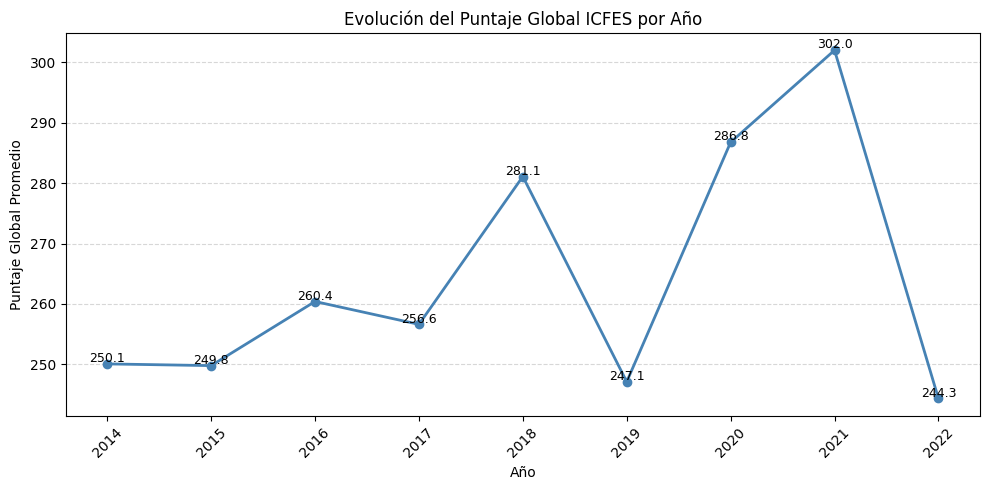

In [14]:
from pyspark.sql.functions import col, avg, substring

# Extraer año y calcular promedio de PUNT_GLOBAL por año
dfAnual = datosIcfes.withColumn("ANO", substring("PERIODO", 1, 4)) \
    .groupBy("ANO") \
    .agg(avg("PUNT_GLOBAL").cast("double").alias("PUNT_GLOBAL_PROM")) \
    .orderBy("ANO").cache()

dfAnual.show()
dfAnual.cache()
import matplotlib.pyplot as plt

# Convertir a pandas
df_pandas = dfAnual.toPandas()
df_pandas["ANO"] = df_pandas["ANO"].astype(int)
df_pandas = df_pandas.sort_values("ANO")

# Gráfico de líneas
plt.figure(figsize=(10, 5))
plt.plot(df_pandas["ANO"], df_pandas["PUNT_GLOBAL_PROM"], marker="o", color="steelblue", linewidth=2)

# Etiquetas en cada punto
for _, row in df_pandas.iterrows():
    plt.text(row["ANO"], row["PUNT_GLOBAL_PROM"] + 0.3, f'{row["PUNT_GLOBAL_PROM"]:.1f}', 
             ha="center", fontsize=9)

plt.xlabel("Año")
plt.ylabel("Puntaje Global Promedio")
plt.title("Evolución del Puntaje Global ICFES por Año")
plt.xticks(df_pandas["ANO"], rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [15]:
pandasDF = datosIcfes.select("PUNT_GLOBAL", "ESTRATO", "EDU_PADRE","EDU_MADRE","TIENE_COMPUTADOR" ).dropna().toPandas()

# Cuarta pregunta. ¿La gestión del Riesgo de los municipios es influyente para el  desempeño global de los estudiantes en el ICFES?

In [37]:
# ==========================================================
# PUNTO 4 - CARGA Y CRUCE DEL DATASET IMRC LIMPIO CON ICFES
# ==========================================================

from pyspark.sql import functions as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# 1. Cargar dataset limpio de IMRC
# ----------------------------------------------------------
# Se prueban varias rutas para evitar que el notebook falle si el archivo
# está en la carpeta del proyecto, en ProyectoPruebas o en data.

rutas_imrc = [
    "datos_limpios_IMRC_Hoja2.csv",
    "../ProyectoPruebas/datos_limpios_IMRC_Hoja2.csv",
    "../data/datos_limpios_IMRC_Hoja2.csv",
    "/mnt/data/datos_limpios_IMRC_Hoja2.csv"
]

datosIMRC = None
ruta_usada_imrc = None
errores_lectura_imrc = []

for ruta in rutas_imrc:
    try:
        temp = (
            sparkSigma.read
            .format("csv")
            .option("header", "true")
            .option("encoding", "UTF-8")
            .option("inferSchema", "true")
            .load(ruta)
        )
        # Acción mínima para validar que realmente se pudo leer.
        temp.limit(1).count()
        datosIMRC = temp
        ruta_usada_imrc = ruta
        break
    except Exception as e:
        errores_lectura_imrc.append((ruta, str(e)[:250]))

if datosIMRC is None:
    print("No se pudo cargar el dataset limpio de IMRC.")
    print("Verifica que el archivo se llame datos_limpios_IMRC_Hoja2.csv y esté en una de estas rutas:")
    for ruta in rutas_imrc:
        print(" -", ruta)
    raise FileNotFoundError("No se encontró el archivo datos_limpios_IMRC_Hoja2.csv")

print("Dataset IMRC cargado desde:", ruta_usada_imrc)
print("Registros IMRC:", datosIMRC.count())
datosIMRC.show(5, truncate=False)

# ----------------------------------------------------------
# 2. Función para normalizar textos de municipios/departamentos
# ----------------------------------------------------------
def normalizar_texto_columna(nombre_columna):
    return F.upper(
        F.trim(
            F.translate(
                F.col(nombre_columna).cast("string"),
                "ÁÉÍÓÚÜÑáéíóúüñ",
                "AEIOUUNaeiouun"
            )
        )
    )

# ----------------------------------------------------------
# 3. Normalización del dataset IMRC
# ----------------------------------------------------------
imrcNormalizado = datosIMRC.select(
    normalizar_texto_columna("MUNICIPIO").alias("NOM_MUN"),
    normalizar_texto_columna("DEPARTAMENTO").alias("DEPTO_IMRC"),
    F.col("IR_D").cast("double").alias("IR_D"),
    F.col("IMRC_D").cast("double").alias("IMRC_D"),
    F.col("IC_D").cast("double").alias("IC_D"),
    F.col("COMP_GESTION_RIESGO").cast("double").alias("COMP_GESTION_RIESGO"),
    F.col("IRD_SEQUIA").cast("double").alias("IRD_SEQUIA"),
    F.col("IRD_INCENDIO").cast("double").alias("IRD_INCENDIO"),
    F.col("PCT_ASE").cast("double").alias("PCT_ASE"),
    F.col("PCT_ASIF").cast("double").alias("PCT_ASIF"),
    F.col("GRUPO_CAPACIDAD").alias("GRUPO_CAPACIDAD")
).dropna(subset=["NOM_MUN", "IMRC_D", "IR_D"])

# ----------------------------------------------------------
# 4. Promedio municipal de ICFES
# ----------------------------------------------------------
# Se calcula de nuevo aquí para que el punto 4 sea autónomo,
# aunque en el punto 2 ya existe una variable similar llamada icfesMunicipal.

icfesRiesgoMunicipal = datosIcfes.select(
    normalizar_texto_columna("COLE_MCPIO_UBICACION").alias("NOM_MUN"),
    F.col("PUNT_GLOBAL").cast("double").alias("PUNT_GLOBAL")
).dropna(subset=["NOM_MUN", "PUNT_GLOBAL"]) \
 .groupBy("NOM_MUN") \
 .agg(
     F.avg("PUNT_GLOBAL").alias("PROM_ICFES"),
     F.count("*").alias("N_ESTUDIANTES_ICFES")
 )

# ----------------------------------------------------------
# 5. Cruce municipal entre ICFES e IMRC
# ----------------------------------------------------------
comparacionRiesgoICFES = icfesRiesgoMunicipal.join(
    imrcNormalizado,
    on="NOM_MUN",
    how="inner"
).dropna(subset=["PROM_ICFES", "IMRC_D", "IR_D", "IC_D"])

print("Municipios en ICFES:", icfesRiesgoMunicipal.count())
print("Municipios en IMRC:", imrcNormalizado.count())
print("Municipios cruzados entre ICFES e IMRC:", comparacionRiesgoICFES.count())

comparacionRiesgoICFES.select(
    "NOM_MUN",
    "PROM_ICFES",
    "N_ESTUDIANTES_ICFES",
    "IR_D",
    "IMRC_D",
    "IC_D",
    "COMP_GESTION_RIESGO",
    "GRUPO_CAPACIDAD"
).orderBy(F.col("IMRC_D").desc()).show(15, truncate=False)


Dataset IMRC cargado desde: datos_limpios_IMRC_Hoja2.csv
Registros IMRC: 1102
+---+--------+------------+--------+-----------+--------------+-------+-------+-------+--------+-----------------+-------------------+---------------------+-----------------------+----------+------------+----+------------------------+----------------+--------------------+-------------------+-------------------+--------+---------------+------+---------+------------+--------------------+-----------------------+-------------------+----+---------------+--------------------+------+
|ID |COD_DPTO|DEPARTAMENTO|DIVIPOLA|MUNICIPIO  |TIPO_MUNICIPIO|ASE_HA |PCT_ASE|ASIF_HA|PCT_ASIF|EXPOSICION_SEQUIA|EXPOSICION_INCENDIO|VULNERABILIDAD_SEQUIA|VULNERABILIDAD_INCENDIO|IRD_SEQUIA|IRD_INCENDIO|IR_D|VALOR_AGREGADO_PERCAPITA|PCT_POB_CABECERA|DENSIDAD_EMPRESARIAL|PCT_VA_AGROPECUARIO|COMP_SOCIOECONOMICO|COMP_MDM|COMP_FINANCIERO|CMGRD |PMGRD    |EMRE        |NUM_HERRAMIENTAS_GRD|INVERSION_GRD_PERCAPITA|COMP_GESTION_RIESGO|IC_D|GRU

In [38]:
# ==========================================================
# PUNTO 4 - CORRELACIONES ENTRE RIESGO MUNICIPAL E ICFES
# ==========================================================

pdfRiesgo = comparacionRiesgoICFES.toPandas()

columnas_riesgo = [
    "IR_D",
    "IMRC_D",
    "IC_D",
    "COMP_GESTION_RIESGO",
    "IRD_SEQUIA",
    "IRD_INCENDIO",
    "PCT_ASE",
    "PCT_ASIF",
    "PROM_ICFES"
]

for columna in columnas_riesgo:
    pdfRiesgo[columna] = pd.to_numeric(pdfRiesgo[columna], errors="coerce")

pdfRiesgo = pdfRiesgo.dropna(subset=["PROM_ICFES", "IR_D", "IMRC_D", "IC_D"])

variables_analisis = [
    "IR_D",
    "IMRC_D",
    "IC_D",
    "COMP_GESTION_RIESGO",
    "IRD_SEQUIA",
    "IRD_INCENDIO",
    "PCT_ASE",
    "PCT_ASIF"
]

resultados_correlacion = []

for variable in variables_analisis:
    temp = pdfRiesgo[[variable, "PROM_ICFES"]].dropna()

    if len(temp) > 2:
        pearson = temp[variable].corr(temp["PROM_ICFES"], method="pearson")
        spearman = temp[variable].corr(temp["PROM_ICFES"], method="spearman")
    else:
        pearson = np.nan
        spearman = np.nan

    resultados_correlacion.append({
        "Variable de riesgo": variable,
        "Correlación Pearson con PROM_ICFES": pearson,
        "Correlación Spearman con PROM_ICFES": spearman,
        "Municipios usados": len(temp)
    })

tabla_correlaciones_riesgo = pd.DataFrame(resultados_correlacion)

print("Tabla de correlaciones entre variables de riesgo e ICFES:")
display(tabla_correlaciones_riesgo)

# Variables principales para la respuesta
corr_imrc_pearson = tabla_correlaciones_riesgo.loc[
    tabla_correlaciones_riesgo["Variable de riesgo"] == "IMRC_D",
    "Correlación Pearson con PROM_ICFES"
].iloc[0]

corr_imrc_spearman = tabla_correlaciones_riesgo.loc[
    tabla_correlaciones_riesgo["Variable de riesgo"] == "IMRC_D",
    "Correlación Spearman con PROM_ICFES"
].iloc[0]

corr_ic_pearson = tabla_correlaciones_riesgo.loc[
    tabla_correlaciones_riesgo["Variable de riesgo"] == "IC_D",
    "Correlación Pearson con PROM_ICFES"
].iloc[0]

print(f"\nCorrelación Pearson IMRC_D vs PROM_ICFES: {corr_imrc_pearson:.3f}")
print(f"Correlación Spearman IMRC_D vs PROM_ICFES: {corr_imrc_spearman:.3f}")
print(f"Correlación Pearson IC_D vs PROM_ICFES: {corr_ic_pearson:.3f}")


Tabla de correlaciones entre variables de riesgo e ICFES:


,Variable de riesgo,Correlación Pearson con PROM_ICFES,Correlación Spearman con PROM_ICFES,Municipios usados
0,IR_D,-0.204149,-0.205778,679
1,IMRC_D,-0.259007,-0.275349,679
2,IC_D,0.276878,0.278254,679
3,COMP_GESTION_RIESGO,-0.012988,0.012446,679
4,IRD_SEQUIA,-0.111645,-0.110845,679
5,IRD_INCENDIO,-0.211082,-0.206098,679
6,PCT_ASE,0.102017,0.129947,679
7,PCT_ASIF,0.019905,0.022636,679



Correlación Pearson IMRC_D vs PROM_ICFES: -0.259
Correlación Spearman IMRC_D vs PROM_ICFES: -0.275
Correlación Pearson IC_D vs PROM_ICFES: 0.277


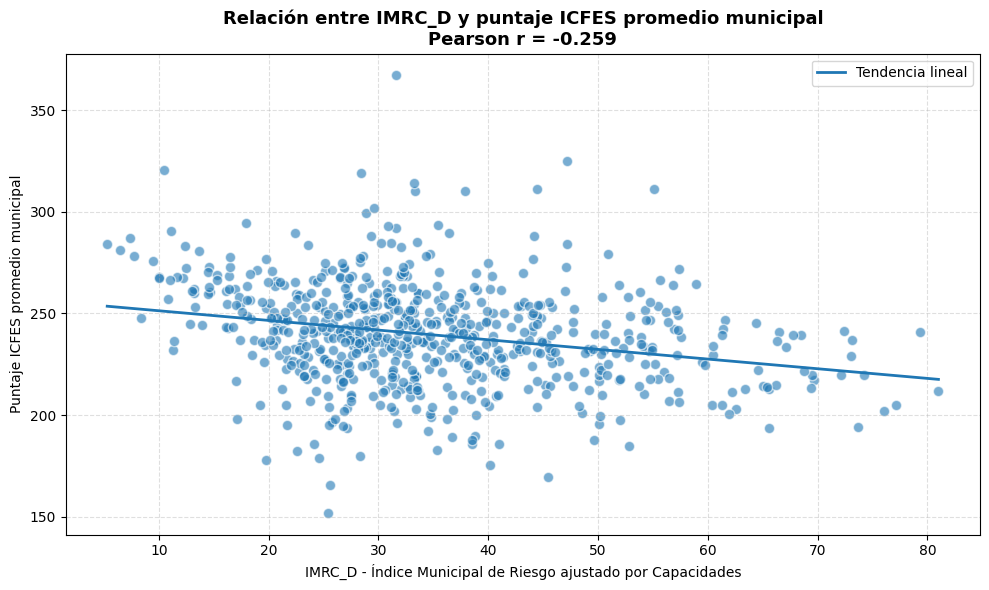

In [39]:
# ==========================================================
# PUNTO 4 - GRÁFICA DE DISPERSIÓN IMRC_D VS ICFES
# ==========================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    pdfRiesgo["IMRC_D"],
    pdfRiesgo["PROM_ICFES"],
    alpha=0.6,
    edgecolors="white",
    s=55
)

# Línea de tendencia
datos_tendencia = pdfRiesgo[["IMRC_D", "PROM_ICFES"]].dropna()

if len(datos_tendencia) > 2:
    m, b = np.polyfit(
        datos_tendencia["IMRC_D"],
        datos_tendencia["PROM_ICFES"],
        1
    )

    x_range = np.linspace(
        datos_tendencia["IMRC_D"].min(),
        datos_tendencia["IMRC_D"].max(),
        100
    )

    plt.plot(
        x_range,
        m * x_range + b,
        linewidth=2,
        label="Tendencia lineal"
    )

plt.title(
    f"Relación entre IMRC_D y puntaje ICFES promedio municipal\nPearson r = {corr_imrc_pearson:.3f}",
    fontsize=13,
    fontweight="bold"
)

plt.xlabel("IMRC_D - Índice Municipal de Riesgo ajustado por Capacidades")
plt.ylabel("Puntaje ICFES promedio municipal")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


Resumen por cuartiles de IMRC_D:


,CUARTIL_IMRC,PROMEDIO_ICFES,MEDIANA_ICFES,PROMEDIO_IMRC,MUNICIPIOS
0,Q1 - Riesgo más bajo,245.448519,247.373098,19.874706,170
1,Q2,242.769588,240.628571,29.032164,171
2,Q3,236.514012,236.097222,36.583929,168
3,Q4 - Riesgo más alto,233.391047,232.487013,53.605294,170


<Figure size 1000x600 with 0 Axes>

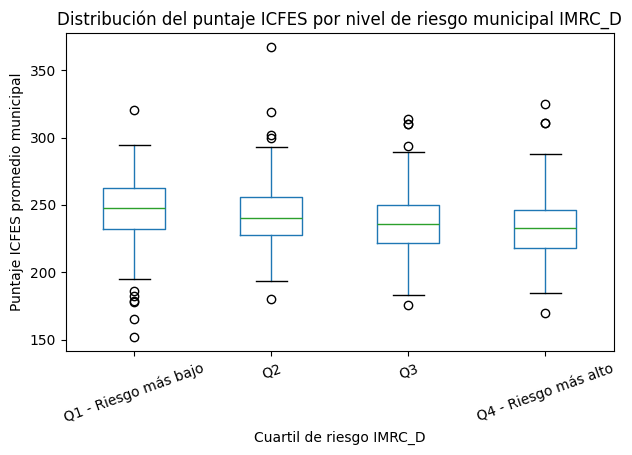

Top 10 municipios con mayor IMRC_D:


,NOM_MUN,PROM_ICFES,IMRC_D,IR_D,IC_D,COMP_GESTION_RIESGO
139,PONEDERA,211.750000,81.0,0.81,0.19,0.03
461,CANDELARIA,240.744681,79.3,1.00,0.29,0.26
591,CAMPO DE LA CRUZ,204.800000,77.1,1.00,0.32,0.29
265,COYAIMA,201.846154,76.0,0.79,0.26,0.25
362,QUIPILE,219.750000,74.2,0.87,0.34,0.33
603,CLEMENCIA,194.000000,73.7,1.00,0.37,0.26
559,SABANALARGA,237.158730,73.1,0.84,0.35,0.25
26,PUERTO ESCONDIDO,229.300000,73.0,0.73,0.27,0.25
83,TARQUI,241.222222,72.4,0.73,0.28,0.00
249,PITAL,219.666667,72.1,0.73,0.29,0.00


Top 10 municipios con menor IMRC_D:


,NOM_MUN,PROM_ICFES,IMRC_D,IR_D,IC_D,COMP_GESTION_RIESGO
467,SABANETA,284.342105,5.3,0.00,0.89,0.80
465,FLORIDABLANCA,281.387324,6.5,0.00,0.87,0.85
486,ENVIGADO,287.319328,7.4,0.00,0.85,0.67
38,TENJO,278.241379,7.7,0.00,0.84,0.70
16,COPACABANA,247.620000,8.4,0.01,0.83,0.88
49,RETIRO,276.000000,9.5,0.00,0.80,0.76
436,LA ESTRELLA,267.357143,10.0,0.00,0.79,0.64
428,MANIZALES,268.017544,10.0,0.01,0.80,0.78
190,COTA,320.348837,10.5,0.00,0.77,0.52
383,BARRANQUILLA,256.905615,10.8,0.00,0.77,0.51


In [40]:
# ==========================================================
# PUNTO 4 - COMPARACIÓN POR NIVELES DE RIESGO
# ==========================================================

# Se crean cuartiles de IMRC_D para comparar el desempeño promedio ICFES
# entre municipios con riesgo bajo, medio y alto.

pdfRiesgo["CUARTIL_IMRC"] = pd.qcut(
    pdfRiesgo["IMRC_D"],
    q=4,
    labels=[
        "Q1 - Riesgo más bajo",
        "Q2",
        "Q3",
        "Q4 - Riesgo más alto"
    ],
    duplicates="drop"
)

resumen_cuartiles_imrc = pdfRiesgo.groupby("CUARTIL_IMRC", observed=False).agg(
    PROMEDIO_ICFES=("PROM_ICFES", "mean"),
    MEDIANA_ICFES=("PROM_ICFES", "median"),
    PROMEDIO_IMRC=("IMRC_D", "mean"),
    MUNICIPIOS=("NOM_MUN", "count")
).reset_index()

print("Resumen por cuartiles de IMRC_D:")
display(resumen_cuartiles_imrc)

plt.figure(figsize=(10, 6))
pdfRiesgo.boxplot(
    column="PROM_ICFES",
    by="CUARTIL_IMRC",
    grid=False,
    rot=20
)

plt.title("Distribución del puntaje ICFES por nivel de riesgo municipal IMRC_D")
plt.suptitle("")
plt.xlabel("Cuartil de riesgo IMRC_D")
plt.ylabel("Puntaje ICFES promedio municipal")
plt.tight_layout()
plt.show()

# Municipios con mayor y menor riesgo para revisar casos extremos
top_riesgo = pdfRiesgo.sort_values("IMRC_D", ascending=False)[
    ["NOM_MUN", "PROM_ICFES", "IMRC_D", "IR_D", "IC_D", "COMP_GESTION_RIESGO"]
].head(10)

bajo_riesgo = pdfRiesgo.sort_values("IMRC_D", ascending=True)[
    ["NOM_MUN", "PROM_ICFES", "IMRC_D", "IR_D", "IC_D", "COMP_GESTION_RIESGO"]
].head(10)

print("Top 10 municipios con mayor IMRC_D:")
display(top_riesgo)

print("Top 10 municipios con menor IMRC_D:")
display(bajo_riesgo)


# Quinta pregunta. ¿Cuáles factores socioeconómicos pueden tener incidencia en el desempeño global de los estudiantes en el ICFES?


A continuación, se analizan factores socioeconómicos individuales del dataset ICFES y, cuando el dataset UNIDOS está correctamente disponible, se complementa con indicadores municipales.

In [16]:
# ==========================================================
# FACTORES SOCIOECONÓMICOS DESDE BASE POBREZA
# ==========================================================

from pyspark.sql import functions as F

factoresPobrezaMunicipal = pobrezaNormalizada \
    .withColumn(
        "TIENE_COMPUTADOR_NUM",
        F.when(F.col("TIENE_COMPUTADOR_POBREZA").isin("SI", "SÍ"), 1)
         .when(F.col("TIENE_COMPUTADOR_POBREZA") == "NO", 0)
         .otherwise(None)
    ) \
    .withColumn(
        "MADRE_EDU_SUPERIOR",
        F.when(
            F.col("EDU_MADRE_POBREZA").contains("PROFESIONAL") |
            F.col("EDU_MADRE_POBREZA").contains("POSTGRADO") |
            F.col("EDU_MADRE_POBREZA").contains("TECNICA") |
            F.col("EDU_MADRE_POBREZA").contains("TECNOL"),
            1
        ).otherwise(0)
    ) \
    .withColumn(
        "PADRE_EDU_SUPERIOR",
        F.when(
            F.col("EDU_PADRE_POBREZA").contains("PROFESIONAL") |
            F.col("EDU_PADRE_POBREZA").contains("POSTGRADO") |
            F.col("EDU_PADRE_POBREZA").contains("TECNICA") |
            F.col("EDU_PADRE_POBREZA").contains("TECNOL"),
            1
        ).otherwise(0)
    ) \
    .groupBy("NOM_MUN") \
    .agg(
        F.avg("ESTRATO_POBREZA").alias("ESTRATO_PROM_POBREZA"),
        F.avg("TIENE_COMPUTADOR_NUM").alias("PROP_COMPUTADOR"),
        F.avg("MADRE_EDU_SUPERIOR").alias("PROP_MADRE_EDU_SUPERIOR"),
        F.avg("PADRE_EDU_SUPERIOR").alias("PROP_PADRE_EDU_SUPERIOR"),
        F.count("*").alias("N_REGISTROS_POBREZA")
    ) \
    .dropna(subset=["NOM_MUN", "ESTRATO_PROM_POBREZA"])

print("Municipios con factores de pobreza:", factoresPobrezaMunicipal.count())

factoresPobrezaMunicipal.orderBy("NOM_MUN").show(10, truncate=False)

Municipios con factores de pobreza: 1394


[Stage 96:==============================================>         (10 + 2) / 12]

+---------+--------------------+-------------------+-----------------------+-----------------------+-------------------+
|NOM_MUN  |ESTRATO_PROM_POBREZA|PROP_COMPUTADOR    |PROP_MADRE_EDU_SUPERIOR|PROP_PADRE_EDU_SUPERIOR|N_REGISTROS_POBREZA|
+---------+--------------------+-------------------+-----------------------+-----------------------+-------------------+
|ABEJORRAL|1.5845347313237221  |0.5051948051948052 |0.11558441558441558    |0.04415584415584416    |770                |
|ABREGO   |1.3862359550561798  |0.35893854748603354|0.13268156424581007    |0.08798882681564246    |716                |
|ABRIAQUI |1.7472527472527473  |0.25               |0.07608695652173914    |0.05434782608695652    |92                 |
|ABRIAQUÍ |1.75                |0.5555555555555556 |0.1111111111111111     |0.1111111111111111     |36                 |
|ACACIAS  |1.7819757365684576  |0.6831546177793151 |0.1895537876167416     |0.13801452784503632    |2891               |
|ACACÍAS  |1.9900579950289976  |

In [17]:
# ==========================================================
# JOIN ENTRE FACTORES DE POBREZA E ICFES
# ==========================================================

factoresICFESPobreza = icfesMunicipal.join(
    factoresPobrezaMunicipal,
    on="NOM_MUN",
    how="inner"
)

factoresICFESPobreza = factoresICFESPobreza.dropna(
    subset=[
        "PROM_ICFES",
        "ESTRATO_PROM_POBREZA",
        "PROP_COMPUTADOR",
        "PROP_MADRE_EDU_SUPERIOR",
        "PROP_PADRE_EDU_SUPERIOR"
    ]
)

print("Municipios cruzados para el análisis:", factoresICFESPobreza.count())

factoresICFESPobreza.select(
    "NOM_MUN",
    "PROM_ICFES",
    "ESTRATO_PROM_POBREZA",
    "PROP_COMPUTADOR",
    "PROP_MADRE_EDU_SUPERIOR",
    "PROP_PADRE_EDU_SUPERIOR",
    "N_REGISTROS_ICFES",
    "N_REGISTROS_POBREZA"
).orderBy("NOM_MUN").show(10, truncate=False)

Municipios cruzados para el análisis: 1233


+---------+------------------+--------------------+-------------------+-----------------------+-----------------------+-----------------+-------------------+
|NOM_MUN  |PROM_ICFES        |ESTRATO_PROM_POBREZA|PROP_COMPUTADOR    |PROP_MADRE_EDU_SUPERIOR|PROP_PADRE_EDU_SUPERIOR|N_REGISTROS_ICFES|N_REGISTROS_POBREZA|
+---------+------------------+--------------------+-------------------+-----------------------+-----------------------+-----------------+-------------------+
|ABEJORRAL|234.11111111111111|1.5845347313237221  |0.5051948051948052 |0.11558441558441558    |0.04415584415584416    |9                |770                |
|ABREGO   |255.5             |1.3862359550561798  |0.35893854748603354|0.13268156424581007    |0.08798882681564246    |8                |716                |
|ABRIAQUI |213.0             |1.7472527472527473  |0.25               |0.07608695652173914    |0.05434782608695652    |2                |92                 |
|ACACIAS  |254.4255319148936 |1.7819757365684576  |0

In [18]:
# ==========================================================
# CORRELACIONES ENTRE FACTORES DE POBREZA E ICFES
# ==========================================================

import pandas as pd
import numpy as np
import builtins
from scipy.stats import pearsonr

pdfFactores = factoresICFESPobreza.toPandas()

columnas_numericas = [
    "PROM_ICFES",
    "ESTRATO_PROM_POBREZA",
    "PROP_COMPUTADOR",
    "PROP_MADRE_EDU_SUPERIOR",
    "PROP_PADRE_EDU_SUPERIOR",
    "N_REGISTROS_ICFES",
    "N_REGISTROS_POBREZA"
]

for columna in columnas_numericas:
    pdfFactores[columna] = pd.to_numeric(pdfFactores[columna], errors="coerce")

pdfFactores = pdfFactores.dropna(subset=columnas_numericas)

factores = {
    "Estrato promedio pobreza": "ESTRATO_PROM_POBREZA",
    "Proporción con computador": "PROP_COMPUTADOR",
    "Proporción madre educación superior": "PROP_MADRE_EDU_SUPERIOR",
    "Proporción padre educación superior": "PROP_PADRE_EDU_SUPERIOR"
}

resultados_correlacion = []

for nombre, columna in factores.items():
    data_temp = pdfFactores[[columna, "PROM_ICFES"]].dropna()

    if len(data_temp) < 2:
        resultados_correlacion.append({
            "FACTOR": nombre,
            "COLUMNA": columna,
            "PEARSON_R": np.nan,
            "VALOR_P": np.nan,
            "OBSERVACION": "No hay suficientes datos"
        })
        continue

    if data_temp[columna].nunique() < 2:
        resultados_correlacion.append({
            "FACTOR": nombre,
            "COLUMNA": columna,
            "PEARSON_R": np.nan,
            "VALOR_P": np.nan,
            "OBSERVACION": "La variable no tiene variación suficiente"
        })
        continue

    r, p = pearsonr(data_temp[columna], data_temp["PROM_ICFES"])

    resultados_correlacion.append({
        "FACTOR": nombre,
        "COLUMNA": columna,
        "PEARSON_R": builtins.round(float(r), 3),
        "VALOR_P": builtins.round(float(p), 4),
        "OBSERVACION": "Calculado correctamente"
    })

tablaCorrelacionesPunto5 = pd.DataFrame(resultados_correlacion)

display(tablaCorrelacionesPunto5)

,FACTOR,COLUMNA,PEARSON_R,VALOR_P,OBSERVACION
0,Estrato promedio pobreza,ESTRATO_PROM_POBREZA,0.231,0.0,Calculado correctamente
1,Proporción con computador,PROP_COMPUTADOR,0.428,0.0,Calculado correctamente
2,Proporción madre educación superior,PROP_MADRE_EDU_SUPERIOR,0.221,0.0,Calculado correctamente
3,Proporción padre educación superior,PROP_PADRE_EDU_SUPERIOR,0.175,0.0,Calculado correctamente


In [19]:
# ==========================================================
# FUNCIÓN PARA GRÁFICAS DE RELACIÓN
# ==========================================================

import matplotlib.pyplot as plt
import numpy as np

def graficar_factor_vs_icfes(df, columna_x, nombre_x, titulo):
    data = df[[columna_x, "PROM_ICFES"]].dropna().copy()

    r, p = pearsonr(data[columna_x], data["PROM_ICFES"])

    plt.figure(figsize=(9, 6))

    plt.scatter(
        data[columna_x],
        data["PROM_ICFES"],
        alpha=0.6,
        color="steelblue",
        edgecolors="white",
        s=55
    )

    m, b = np.polyfit(
        data[columna_x],
        data["PROM_ICFES"],
        1
    )

    x_range = np.linspace(
        data[columna_x].min(),
        data[columna_x].max(),
        100
    )

    plt.plot(
        x_range,
        m * x_range + b,
        color="tomato",
        linewidth=2,
        label="Tendencia lineal"
    )

    plt.title(
        f"{titulo}\nPearson r = {r:.3f}",
        fontsize=13,
        fontweight="bold"
    )

    plt.xlabel(nombre_x)
    plt.ylabel("Puntaje ICFES promedio")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()

**Lectura parcial:** En las variables individuales del ICFES se espera observar diferencias en la distribución del puntaje global según estrato, educación de los padres y tenencia de computador. Si las medianas y los rangos intercuartílicos suben en categorías socioeconómicas más favorables, esto sugiere incidencia positiva de mejores condiciones del hogar sobre el desempeño académico.


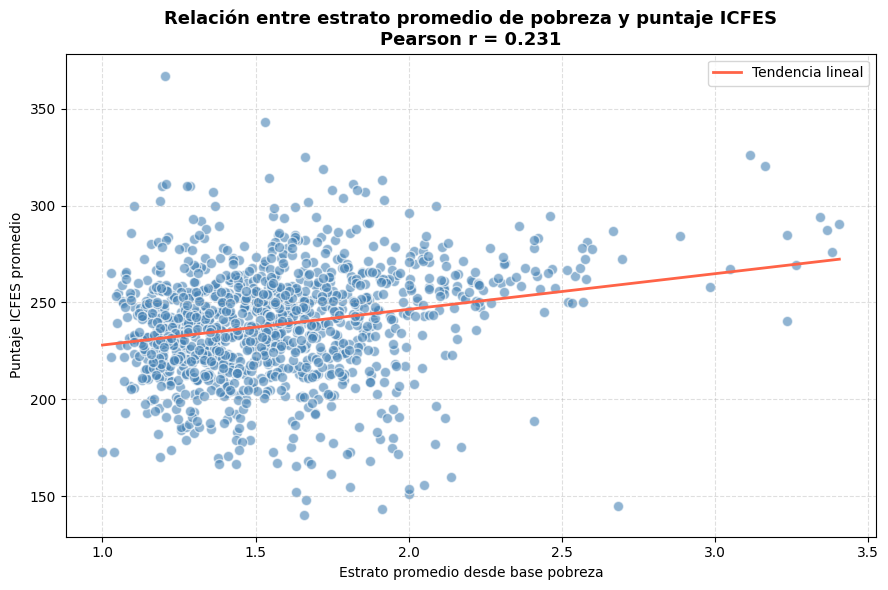

In [20]:
# ==========================================================
# GRÁFICA 1: ESTRATO PROMEDIO DE POBREZA VS ICFES
# ==========================================================

graficar_factor_vs_icfes(
    pdfFactores,
    "ESTRATO_PROM_POBREZA",
    "Estrato promedio desde base pobreza",
    "Relación entre estrato promedio de pobreza y puntaje ICFES"
)

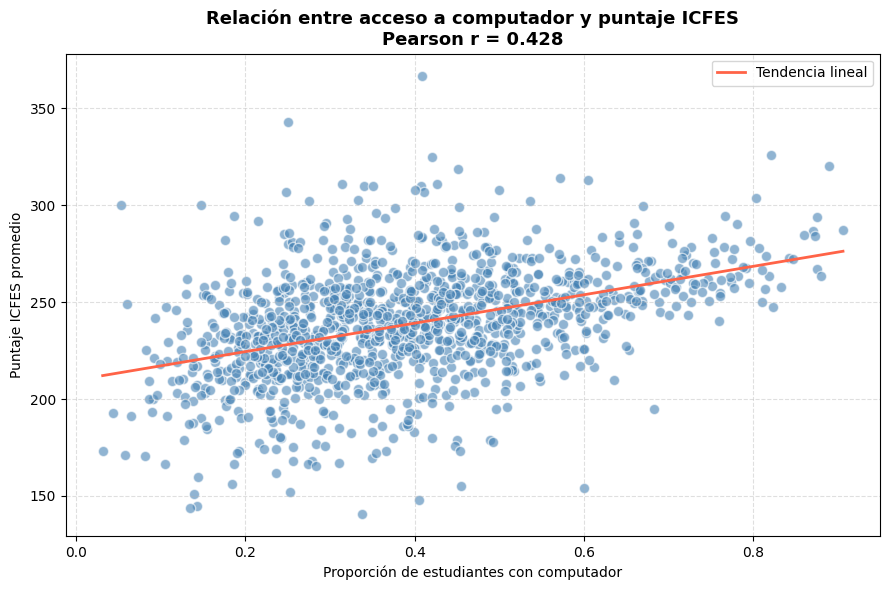

In [21]:
# ==========================================================
# GRÁFICA 2: ACCESO A COMPUTADOR VS ICFES
# ==========================================================

graficar_factor_vs_icfes(
    pdfFactores,
    "PROP_COMPUTADOR",
    "Proporción de estudiantes con computador",
    "Relación entre acceso a computador y puntaje ICFES"
)

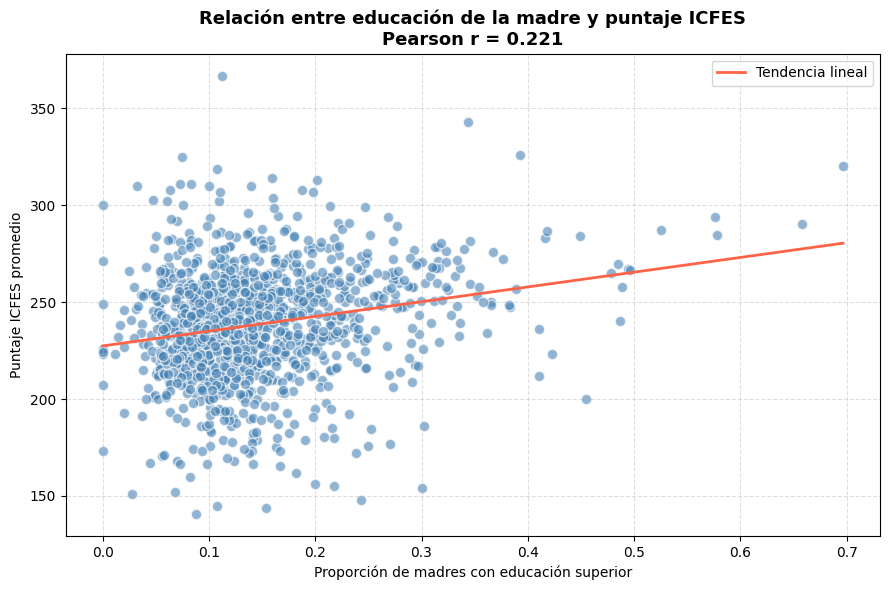

In [22]:
# ==========================================================
# GRÁFICA 3: EDUCACIÓN DE LA MADRE VS ICFES
# ==========================================================

graficar_factor_vs_icfes(
    pdfFactores,
    "PROP_MADRE_EDU_SUPERIOR",
    "Proporción de madres con educación superior",
    "Relación entre educación de la madre y puntaje ICFES"
)

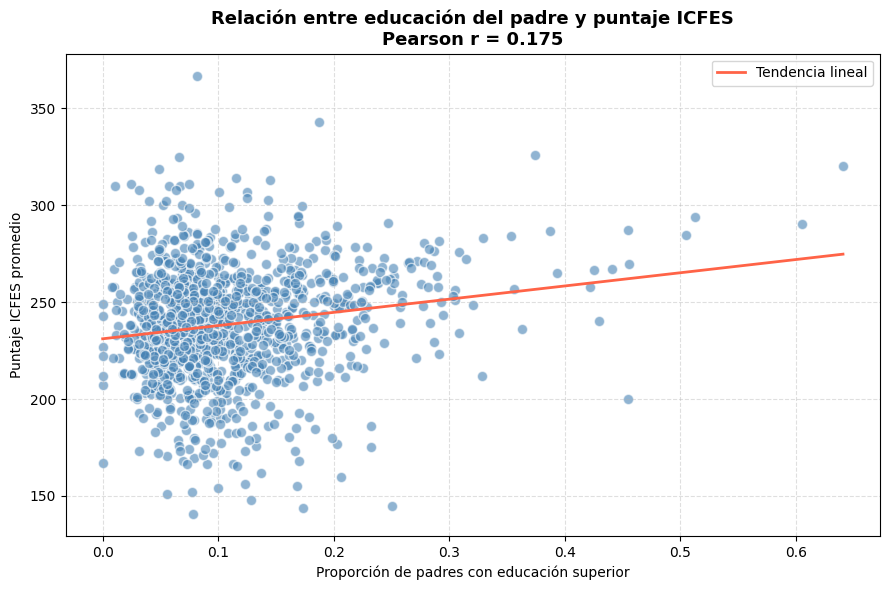

In [23]:
# ==========================================================
# GRÁFICA 4: EDUCACIÓN DEL PADRE VS ICFES
# ==========================================================

graficar_factor_vs_icfes(
    pdfFactores,
    "PROP_PADRE_EDU_SUPERIOR",
    "Proporción de padres con educación superior",
    "Relación entre educación del padre y puntaje ICFES"
)

**Respuesta:** Los resultados muestran que algunos factores socioeconómicos de la base de pobreza se relacionan con el desempeño promedio en el ICFES. Para este análisis se cruzaron las bases de pobreza e ICFES a nivel municipal, usando `NOM_MUN` como llave común. A partir de este cruce se comparó el puntaje ICFES promedio con variables como el estrato promedio, la proporción de estudiantes con computador y la proporción de padres o madres con educación superior.

En general, los municipios con mejores condiciones socioeconómicas y mayor acceso a recursos familiares y tecnológicos tienden a presentar mejores resultados promedio en el ICFES. Esto sugiere que el desempeño académico está relacionado con el contexto de pobreza y las condiciones del hogar, no solamente con factores escolares. No obstante, las correlaciones obtenidas deben entenderse como asociaciones, ya que otros factores territoriales, institucionales y educativos también pueden influir en los resultados.

# Sexta pregunta de negocio ¿Cuáles son las regiones del país que tienen resultados ICFES muy buenos o muy malos?

Top 5 mejores departamentos
  DEPTO_COLEGIO    PROMEDIO
0        BOGOTA  272.292517
1     SANTANDER  264.006159
2        BOYACA  263.522251
3  CUNDINAMARCA  262.158605
4     RISARALDA  257.485149

Top 5 peores departamentos
  DEPTO_COLEGIO    PROMEDIO
0         CHOCO  215.735426
1        VAUPES  217.000000
2      AMAZONAS  219.186047
3    LA GUAJIRA  228.343915
4     MAGDALENA  230.421687


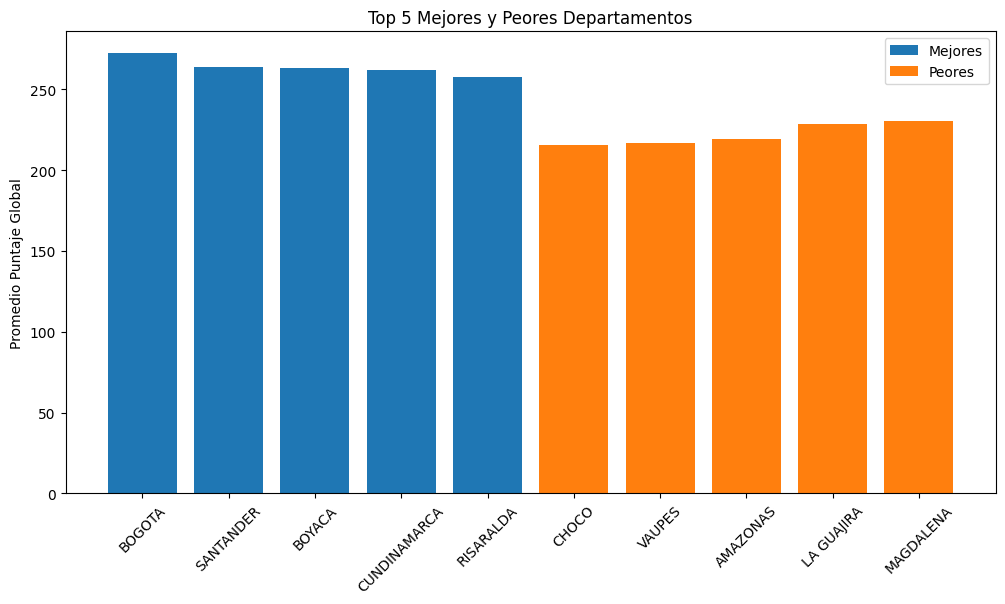

In [24]:
from pyspark.sql.functions import avg, col
import matplotlib.pyplot as plt
import pandas as pd
datosIcfes = datosIcfes.withColumn(
    "DEPTO_COLEGIO",
    when(col("DEPTO_COLEGIO") == "BOGOTÁ", "BOGOTA")
    .otherwise(col("DEPTO_COLEGIO"))
)
# =========================
# TOP 5 DEPARTAMENTOS
# =========================

# Promedio por departamento
depProm = datosIcfes.groupBy("DEPTO_COLEGIO") \
    .agg(avg("PUNT_GLOBAL").alias("PROMEDIO")) \
    .dropna()

# Top 5 mejores
top5Dep = depProm.orderBy(col("PROMEDIO").desc()).limit(5).toPandas()

# Top 5 peores
worst5Dep = depProm.orderBy(col("PROMEDIO").asc()).limit(5).toPandas()

print("Top 5 mejores departamentos")
print(top5Dep)

print("\nTop 5 peores departamentos")
print(worst5Dep)

# =========================
# GRÁFICA DEPARTAMENTOS
# =========================

fig, ax = plt.subplots(figsize=(12,6))

# Unir ambos
depGraf = pd.concat([
    top5Dep.assign(TIPO="Mejores"),
    worst5Dep.assign(TIPO="Peores")
])

# Barras
for tipo in depGraf["TIPO"].unique():
    subset = depGraf[depGraf["TIPO"] == tipo]
    
    ax.bar(
        subset["DEPTO_COLEGIO"],
        subset["PROMEDIO"],
        label=tipo
    )

ax.set_title("Top 5 Mejores y Peores Departamentos")
ax.set_ylabel("Promedio Puntaje Global")
ax.tick_params(axis='x', rotation=45)

plt.legend()
plt.show()



- Se evidencia que los departamentos con peor puntaje tienen una característica en común: Estan geográficamente alejados del centro del país.
- Se evidencia que los departamentos con mejor puntaje tienen la característica común contraria, estan cercanos al centro del país de forma geográfica

Top 5 mejores municipios
  COLE_MCPIO_UBICACION    PROMEDIO
0           GUACAMAYAS  367.000000
1             GONZÁLEZ  343.000000
2                 SOPÓ  326.000000
3            BOCHALEMA  325.000000
4                 COTA  320.348837

Top 5 peores municipios
  COLE_MCPIO_UBICACION    PROMEDIO
0              EBÉJICO  140.500000
1               BAGADÓ  143.666667
2           ALTO BAUDÓ  145.000000
3                VÉLEZ  148.000000
4            RÍO QUITO  151.000000


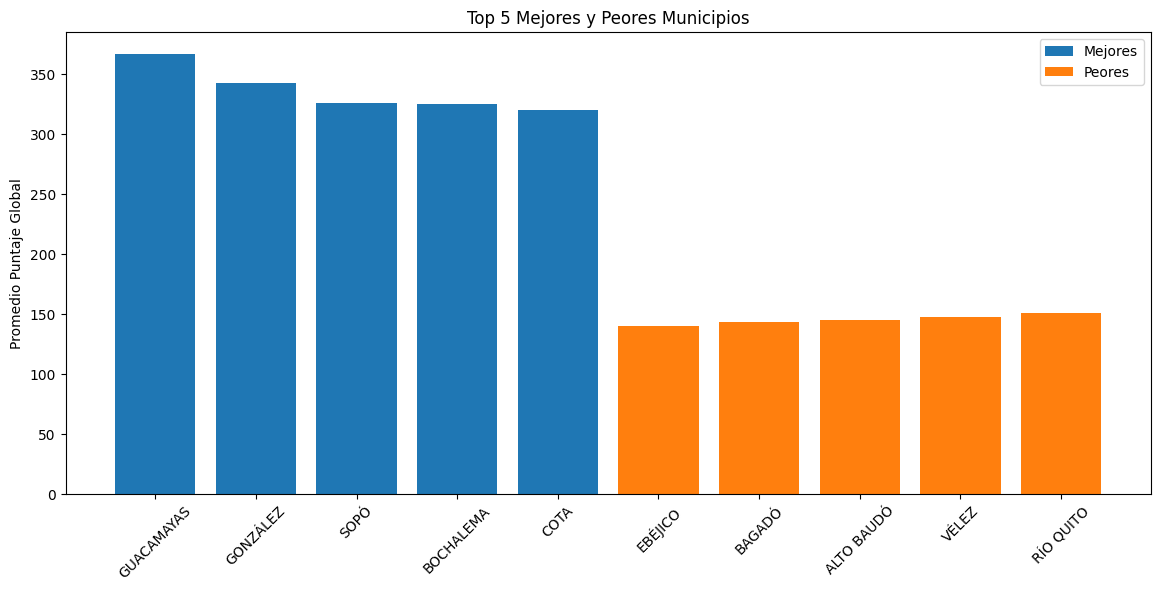

In [25]:

# =========================
# TOP 5 MUNICIPIOS
# =========================

# Promedio por municipio
munProm = datosIcfes.groupBy("COLE_MCPIO_UBICACION") \
    .agg(avg("PUNT_GLOBAL").alias("PROMEDIO")) \
    .dropna()

# Top 5 mejores municipios
top5Mun = munProm.orderBy(col("PROMEDIO").desc()).limit(5).toPandas()

# Top 5 peores municipios
worst5Mun = munProm.orderBy(col("PROMEDIO").asc()).limit(5).toPandas()

print("Top 5 mejores municipios")
print(top5Mun)

print("\nTop 5 peores municipios")
print(worst5Mun)

# =========================
# GRÁFICA MUNICIPIOS
# =========================

fig, ax = plt.subplots(figsize=(14,6))

# Unir ambos
munGraf = pd.concat([
    top5Mun.assign(TIPO="Mejores"),
    worst5Mun.assign(TIPO="Peores")
])

# Barras
for tipo in munGraf["TIPO"].unique():
    subset = munGraf[munGraf["TIPO"] == tipo]
    
    ax.bar(
        subset["COLE_MCPIO_UBICACION"],
        subset["PROMEDIO"],
        label=tipo
    )

ax.set_title("Top 5 Mejores y Peores Municipios")
ax.set_ylabel("Promedio Puntaje Global")
ax.tick_params(axis='x', rotation=45)

plt.legend()
plt.show()

- Existe una gran diferencia entre los municipios "buenos" y "malos", es aprixamademente de doble en todos los casos, nótese que los municipios con peor puntaje promedio son zonas rurales, de hecho, los municipios de Bagadó, Alto Baudó, Río Quito pertenecen al departamento del chocó, que es una zona conocida por la alta ruralidad y la pobreza multidimensional.

- Respecto a lo anterior, se puede inferir que aquí ocurre el mismo fenómeno que en los departamentos, zonas alejadas del centro tienden a peores puntajes y viceversa, de hecho, nótese como 3 de los municipios pertenecen al chocó, que fue el peor departamento. Así como Sopo y Cota están cerca de la capital Bogota, que obtuvo el mejor promedio de los departamentos

# Septima pregunta de negocio ¿Cuál es la incidencia de los resultados SABER 11 en el ingreso a la educación superior?

In [30]:
## Se crea el dataframe para acceder al sistema de fichero csv como un objeto dataframe pyspark
## El acceso se hara desde el sistema de ficheros Hadoop HDFS
datosMatriculas = sparkSigma.read.format("csv").option("header","true").option("encoding", "UTF-8").load("../ProyectoPruebas/MEN_ESTADISTICAS_MATRICULA_POR_MUNICIPIOS_ES_20260407.txt")
datosMatriculas.show(2)


[Stage 133:>                                                        (0 + 1) / 1]

+----+----------------------+-----------------------+-------------------+--------------------+-------------------+-----------+-------------+---------------+--------+---------+--------------+
| AÑO|Código delDepartamento|Nombre del Departamento|Código delMunicipio|Nombre del Municipio|TECNICA PROFESIONAL|TECNOLOGICA|UNIVERSITARIA|ESPECIALIZACION|MAESTRIA|DOCTORADO|IES CON OFERTA|
+----+----------------------+-----------------------+-------------------+--------------------+-------------------+-----------+-------------+---------------+--------+---------+--------------+
|2005|                    11|                     11|              11001|         BOGOTÁ D.C.|             63,098|     40,178|      279,544|         23,603|   7,399|      492|           106|
|2005|                    13|                     13|              13001| CARTAGENA DE INDIAS|              5,902|      4,348|       25,138|          1,260|       9|        0|            33|
+----+----------------------+----------------

+----+-------------------+------------------+
| ANO|TOTAL_UNIVERSITARIA|  PUNT_GLOBAL_PROM|
+----+-------------------+------------------+
|2014|            66780.0|250.05922462497566|
|2015|            66152.0|249.77450796626056|
|2016|            58616.0|260.39367441860463|
|2017|            55530.0|256.60619300911856|
|2018|            52084.0|  281.094674556213|
|2019|            56372.0|247.09939934121294|
|2020|            63864.0|286.76646706586826|
|2021|            33395.0| 302.0066225165563|
+----+-------------------+------------------+



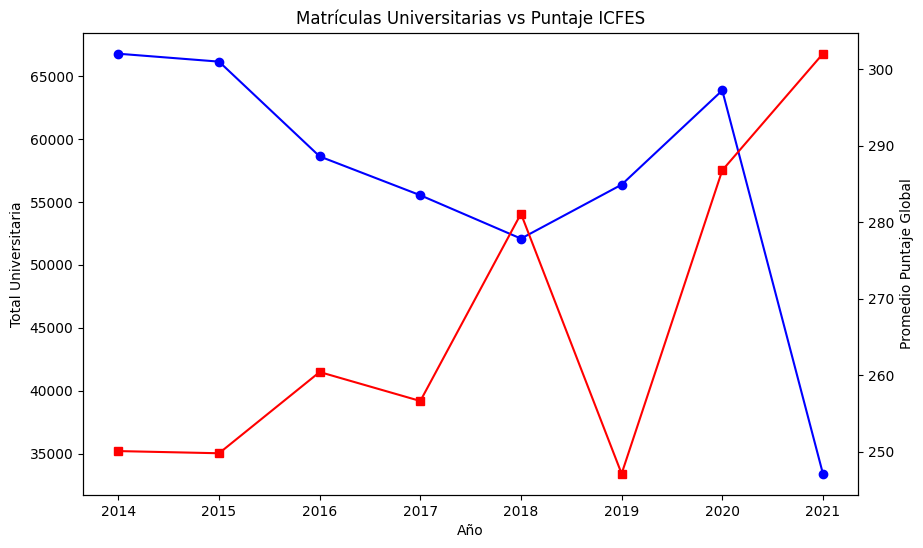

In [31]:
from pyspark.sql.functions import avg, sum, col
import matplotlib.pyplot as plt
import pandas as pd

# =========================
# AGRUPAR MATRÍCULAS UNIVERSITARIAS POR AÑO
# =========================

universitaria = datosMatriculas.groupBy("AÑO") \
    .agg(
        sum("UNIVERSITARIA").alias("TOTAL_UNIVERSITARIA")
    )

# =========================
# PROMEDIO ICFES POR AÑO
# =========================
dfAnual = dfAnual.withColumnRenamed("AÑO", "ANO")
universitaria=universitaria.withColumnRenamed("AÑO", "ANO")

# =========================
# INNER JOIN POR AÑO
# =========================

comparacion = universitaria.join(
    dfAnual,
    on="ANO",
    how="inner"
).orderBy("ANO")

# Mostrar resultado
comparacion.show()

# =========================
# PASAR A PANDAS
# =========================

pdf = comparacion.toPandas()

# =========================
# GRÁFICA
# =========================

fig, ax1 = plt.subplots(figsize=(10,6))

# Línea matrículas
ax1.plot(
    pdf["ANO"],
    pdf["TOTAL_UNIVERSITARIA"],
    marker="o",
    color="blue",
    label="Universitaria"
)



ax1.set_xlabel("Año")
ax1.set_ylabel("Total Universitaria")

# Segundo eje
ax2 = ax1.twinx()

ax2.plot(
    pdf["ANO"],
    pdf["PUNT_GLOBAL_PROM"],
    marker="s",
    color="red",
    label="ICFES"
)

ax2.set_ylabel("Promedio Puntaje Global")

plt.title("Matrículas Universitarias vs Puntaje ICFES")

plt.show()

No se puede decir respecto a esta gráfica que haya una incidencia del puntaje global en la admision universitaria respecto a la temporalidad analizada

No obstante, esto si se puede observar por municipios, de forma similar que en una pregunta anterior


Se aclara que el hecho de que el puntaje global bajo ocurra cuando hay baja tasa de admisibilidad no implica que un factor sea la causa del otro. Las zonas que presentan bajo puntaje promedio tienen dificultades en el acceso a la educación básica, y eso, entre otros factores, puede significar que la admisibilidad universitaria sea baja también .

In [32]:
from pyspark.sql.functions import avg, sum, col

# =========================================
# PROMEDIO ICFES POR MUNICIPIO
# =========================================

icfesMun = datosIcfes.groupBy("COLE_MCPIO_UBICACION") \
    .agg(
        avg("PUNT_GLOBAL").alias("PROMEDIO_ICFES")
    )
icfesMun=icfesMun.withColumnRenamed("COLE_MCPIO_UBICACION","MUNICIPIO")
# =========================================
# UNIVERSITARIA POR MUNICIPIO
# =========================================

uniMun = datosMatriculas.groupBy("Nombre del Municipio") \
    .agg(
        sum("UNIVERSITARIA").alias("TOTAL_UNIVERSITARIA")
    )
uniMun=uniMun.withColumnRenamed("Nombre del Municipio","MUNICIPIO")
# =========================================
# INNER JOIN
# =========================================

comparacion = icfesMun.join(
    uniMun,
    on="MUNICIPIO",
    how="inner"
)

# =========================================
# TOP 5 MEJORES
# =========================================

top5Mun = comparacion.orderBy(
    col("PROMEDIO_ICFES").desc()
).limit(5)

print("TOP 5 MEJORES MUNICIPIOS")
top5Mun.show(truncate=False)

# =========================================
# TOP 5 PEORES
# =========================================

worst5Mun = comparacion.orderBy(
    col("PROMEDIO_ICFES").asc()
).limit(5)

print("TOP 5 PEORES MUNICIPIOS")
worst5Mun.show(truncate=False)

TOP 5 MEJORES MUNICIPIOS


+------------+-----------------+-------------------+
|MUNICIPIO   |PROMEDIO_ICFES   |TOTAL_UNIVERSITARIA|
+------------+-----------------+-------------------+
|GONZÁLEZ    |343.0            |2.0                |
|SOPÓ        |326.0            |2.0                |
|BOCHALEMA   |325.0            |6.0                |
|COTA        |320.3488372093023|2.0                |
|EL GUACAMAYO|319.0            |0.0                |
+------------+-----------------+-------------------+

TOP 5 PEORES MUNICIPIOS


[Stage 162:>                                                        (0 + 1) / 1]

+------------+------------------+-------------------+
|MUNICIPIO   |PROMEDIO_ICFES    |TOTAL_UNIVERSITARIA|
+------------+------------------+-------------------+
|EBÉJICO     |140.5             |152.0              |
|BAGADÓ      |143.66666666666666|45.0               |
|ALTO BAUDÓ  |145.0             |4.0                |
|VÉLEZ       |148.0             |5885.0             |
|VISTAHERMOSA|152.0             |12.0               |
+------------+------------------+-------------------+



Como se ha dicho anteriormente, la tasa de admisión y el puntaje global del icfes no puede ser tan facilmente comparados, fijése que altas y bajas tasas de admisión universitaria aparecen en los mejores o peores municipios en relación al puntaje global de la prueba.

La admisión a universidades depende primordialmente de , por ejemplo, la cantidad de universidades en la región, o si la universidad tiene un criterio de selección basado en el puntaje icfes.

# Octava pregunta de negocio. ¿Qué nos muestran las estadísticas municipales de educación respecto a la calidad Nacional educativa?

In [33]:
datosEstadisticas = sparkSigma.read.format("csv").option("header","true").option("encoding", "UTF-8").load("../ProyectoPruebas/MEN_ESTADISTICAS_EN_EDUCACION_EN_PREESCOLAR,_BÁSICA_Y_MEDIA_POR_MUNICIPIO_20260407.txt")
datosEstadisticas.show(2)

[Stage 164:>                                                        (0 + 1) / 1]

+----+----------------+---------+-------------------+------------+----------+---------------+--------------+-----------------------+--------------+-------------------------+-----------------------+-------------------------+--------------------+---------------+--------------------------+------------------------+--------------------------+---------------------+------------------------+---------------------------+---------+--------------------+------------------+--------------------+---------------+----------+---------------------+-------------------+---------------------+----------------+-----------+----------------------+--------------------+----------------------+-----------------+----------+---------------------+-------------------+---------------------+----------------+
| AÑO|CÓDIGO_MUNICIPIO|MUNICIPIO|CÓDIGO_DEPARTAMENTO|DEPARTAMENTO|CÓDIGO_ETC|            ETC|POBLACIÓN_5_16|TASA_MATRICULACIÓN_5_16|COBERTURA_NETA|COBERTURA_NETA_TRANSICIÓN|COBERTURA_NETA_PRIMARIA|COBERTURA_NETA_SECUN

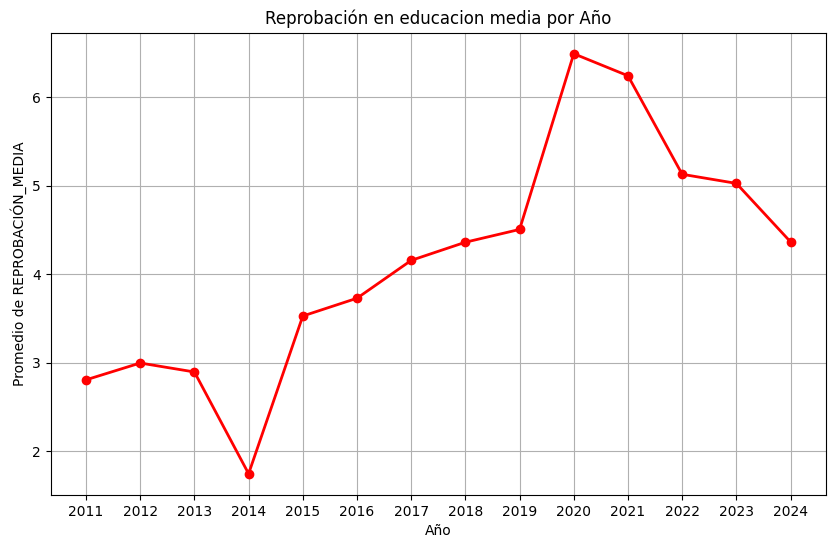

In [34]:

import pyspark.sql.functions as F

# Divide por 100 para convertir "45" en "0.45"
datosEstadisticas= datosEstadisticas.withColumn(
    "REPROBACIÓN_MEDIA", 
    (F.regexp_replace("REPROBACIÓN_MEDIA", "%", "").cast("double")) 
)
# =========================================
# AGRUPAR REPITENCIA POR AÑO
# =========================================

repitencia = datosEstadisticas.groupBy("AÑO") \
    .avg("REPROBACIÓN_MEDIA") \
    .orderBy("AÑO")

# Pasar a pandas
pdf = repitencia.toPandas()

# Renombrar columna promedio
pdf = pdf.rename(
    columns={"avg(REPROBACIÓN_MEDIA)": "PROM_REPROBACIÓN_MEDIA"}
)

# =========================================
# GRÁFICO DE LÍNEAS
# =========================================

plt.figure(figsize=(10,6))

plt.plot(
    pdf["AÑO"],
    pdf["PROM_REPROBACIÓN_MEDIA"],
    marker="o",
    color="red",
    linewidth=2
)

plt.title("Reprobación en educacion media por Año")
plt.xlabel("Año")
plt.ylabel("Promedio de REPROBACIÓN_MEDIA")

plt.grid(True)

plt.show()

- Se puede apreciar que en los años recientes se han hecho esfuerzos de algún tipo para disminuir la reprobación escolar en el nivel medio, no obstante, se detalla que la disminución de los últimos 5 años viene desde un pico que se obtuvo en el año 2020 (Coincidencialmente tras la pandemia. Se puede decir que los esfuerzos que se han hecho deben seguirse haciendo. 

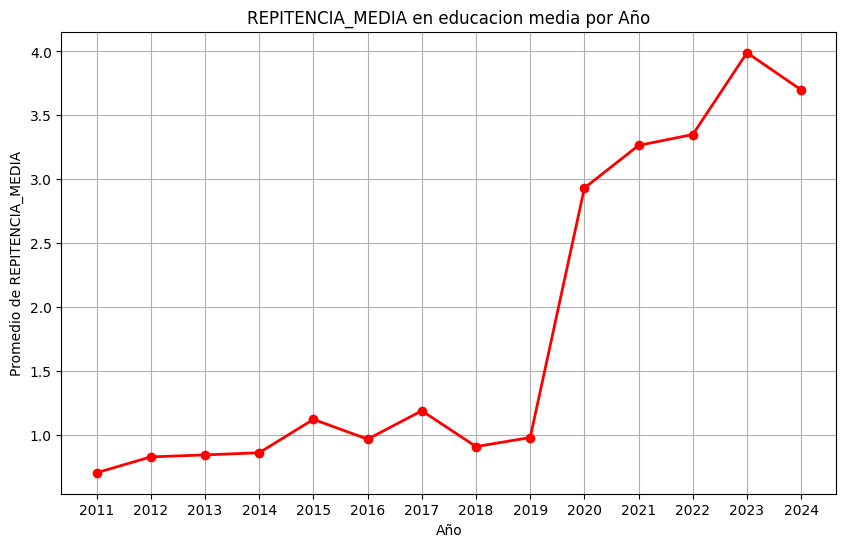

In [35]:

import pyspark.sql.functions as F

# Divide por 100 para convertir "45" en "0.45"
datosEstadisticas= datosEstadisticas.withColumn(
    "REPITENCIA_MEDIA", 
    (F.regexp_replace("REPITENCIA_MEDIA", "%", "").cast("double")) 
)
# =========================================
# AGRUPAR REPITENCIA POR AÑO
# =========================================

repitencia = datosEstadisticas.groupBy("AÑO") \
    .avg("REPITENCIA_MEDIA") \
    .orderBy("AÑO")

# Pasar a pandas
pdf = repitencia.toPandas()

# Renombrar columna promedio
pdf = pdf.rename(
    columns={"avg(REPITENCIA_MEDIA)": "PROM_REPITENCIA_MEDIA"}
)

# =========================================
# GRÁFICO DE LÍNEAS
# =========================================

plt.figure(figsize=(10,6))

plt.plot(
    pdf["AÑO"],
    pdf["PROM_REPITENCIA_MEDIA"],
    marker="o",
    color="red",
    linewidth=2
)

plt.title("REPITENCIA_MEDIA en educacion media por Año")
plt.xlabel("Año")
plt.ylabel("Promedio de REPITENCIA_MEDIA")

plt.grid(True)

plt.show()

- Se observa que existe un aumento importante de la tasa de repitencia en el nivel medio, se sugieren realizar políticas públicas enfocadas a garantizar la persistencia de los jóvenes en los planteles educativos.